<a href="https://colab.research.google.com/github/pranathigadhanki-alt/stock-prediction-ml-/blob/main/ML5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#Step 0
!pip install yfinance scikit-learn pandas matplotlib seaborn

In [24]:
#Step 1a: Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_13862/1816335882.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Configuration loaded. Predicting price direction for: AAPL

Dataset has 1509 trading days

First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.304169  40.313530  39.602250  39.812828  102223600
2018-01-03  40.297153  40.839972  40.233983  40.367346  118071600
2018-01-04  40.484341  40.587289  40.262067  40.369693   89738400
2018-01-05  40.945263  41.031832  40.489016  40.580266   94640000
2018-01-08  40.793175  41.087979  40.694903  40.793175   82271200

Basic statistics:
Price         Close         High          Low         Open        Volume
Ticker         AAPL         AAPL         AAPL         AAPL          AAPL
count   1509.000000  1509.000000  1509.000000  1509.000000  1.509000e+03
mean     107.723608   108.850195   106.484611   107.623746  1.073284e+08
std       50.886479    51.359839    50.359434    50.8455

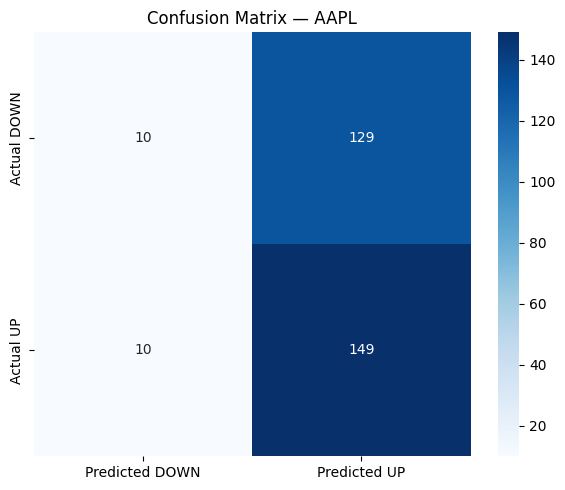

Confusion matrix saved as confusion_matrix.png


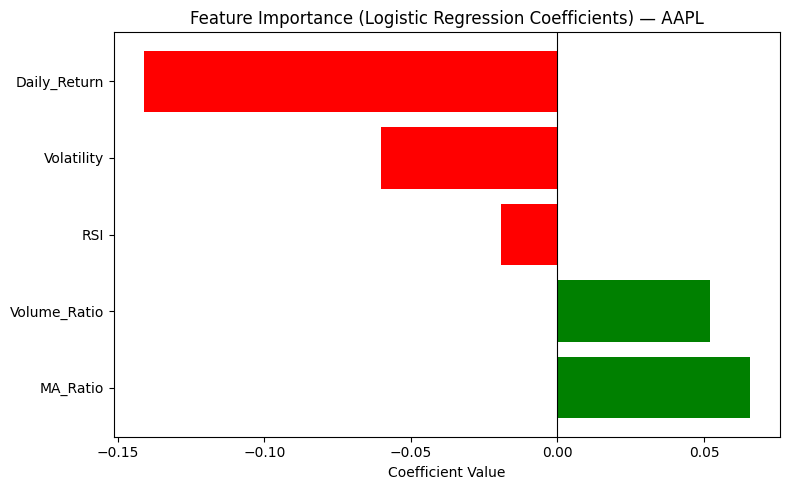

/tmp/ipykernel_13862/1816335882.py:213: FutureWarning: YF.download() has changed argument auto_adjust default to True
  live_df = yf.download(TICKER, period="60d")
[*********************100%***********************]  1 of 1 completed

Feature importance chart saved as feature_importance.png

── Live Prediction (Most Recent Trading Day) ──


Latest date:       2026-04-16
Predicted move:    UP ↑
Model confidence:  56.4%
  P(DOWN): 43.6%  |  P(UP): 56.4%

⚠️  Disclaimer: This project is for educational purposes ONLY.
    Do NOT use this model to make real investment decisions.


In [25]:
#Step 1b: Importing from sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# ── Settings ──────────────────────────────────────────────────
# Change TICKER to any stock symbol you want to experiment with.
TICKER       = "AAPL"        # Apple Inc. — try "TSLA", "MSFT", "NVDA", etc.
START_DATE   = "2018-01-01"  # Beginning of historical data window
END_DATE     = "2024-01-01"  # End of historical data window
TEST_SIZE    = 0.2            # 20% of data goes to testing, 80% to training
RANDOM_STATE = 42             # Fixes randomness so results are reproducible

print(f"Configuration loaded. Predicting price direction for: {TICKER}")


# ============================================================
# STEP 2: Download & Explore the Data
# ============================================================
# yf.download() hits Yahoo Finance and returns a pandas DataFrame.
# Each row = one trading day; columns include Open, High, Low, Close, Volume.

df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# --- Explore the data ---
print(f"\nDataset has {len(df)} trading days")
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic statistics:")
print(df.describe())


# ============================================================
# STEP 3: Feature Engineering
# ============================================================
# Raw prices are noisy. We compute "technical indicators" —
# derived signals that summarise momentum, trend, and risk.
# Better features → smarter model.

# yfinance sometimes returns MultiIndex columns in Colab — flatten them.
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ── Feature 1: Daily Return ───────────────────────────────────
# How much did the stock move today, as a fraction of yesterday's price?
# pct_change() computes (today - yesterday) / yesterday for every row.
df["Daily_Return"] = df["Close"].pct_change()

# ── Feature 2: Moving Averages & MA Ratio ────────────────────
# A moving average smooths price fluctuations over a window of days.
# MA_Ratio > 1  → short-term trend is ABOVE long-term trend (bullish)
# MA_Ratio < 1  → short-term trend is BELOW long-term trend (bearish)
df["MA5"]      = df["Close"].rolling(window=5).mean()
df["MA20"]     = df["Close"].rolling(window=20).mean()
df["MA_Ratio"] = df["MA5"] / df["MA20"]

# ── Feature 3: Volatility ─────────────────────────────────────
# Standard deviation of daily returns over 5 days.
# High volatility = lots of uncertainty recently.
df["Volatility"] = df["Daily_Return"].rolling(window=5).std()

# ── Feature 4: Volume Ratio ───────────────────────────────────
# Today's volume divided by its 20-day average.
# Ratio > 1 → unusually high trading activity (can signal big moves).
df["Volume_Ratio"] = df["Volume"] / df["Volume"].rolling(window=20).mean()

# ── Feature 5: RSI (Relative Strength Index) ──────────────────
# RSI is a 0-100 momentum indicator.
#   RSI > 70 → stock may be "overbought"  (price might fall)
#   RSI < 30 → stock may be "oversold"    (price might rise)
delta    = df["Close"].diff()                     # Day-over-day price change
gain     = delta.clip(lower=0)                    # Keep only positive changes
loss     = -delta.clip(upper=0)                   # Keep only negative changes (flip sign)
avg_gain = gain.rolling(window=14).mean()         # Average gain over 14 days
avg_loss = loss.rolling(window=14).mean()         # Average loss over 14 days
rs       = avg_gain / avg_loss                    # Relative strength ratio
df["RSI"] = 100 - (100 / (1 + rs))               # Classic RSI formula

# ── Target Variable ───────────────────────────────────────────
# We want to predict whether TOMORROW's close is higher than TODAY's.
# shift(-1) pulls the NEXT row's Close into the current row.
# .astype(int) converts True → 1 (UP) and False → 0 (DOWN).
df["Target"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

# ── Drop rows with NaN ────────────────────────────────────────
# Rolling windows and pct_change leave NaN at the start — remove them.
df.dropna(inplace=True)

print(f"\nFeatures created! Dataset has {len(df)} usable rows.")
print(f"Class balance — UP: {df['Target'].sum()} | DOWN: {(df['Target']==0).sum()}")


# ============================================================
# STEP 4: Prepare Data for the Model
# ============================================================
# X = inputs (features the model learns from)
# y = output (what we want to predict)
# Then we split into train/test sets and scale the features.

FEATURES = ["Daily_Return", "MA_Ratio", "Volatility", "Volume_Ratio", "RSI"]

X = df[FEATURES]   # Input features — shape: (rows, 5)
y = df["Target"]   # Labels — shape: (rows,)

# ── Train / Test Split ────────────────────────────────────────
# shuffle=False is CRITICAL for time-series data.
# If we shuffle, future data could leak into training — that's cheating!
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    shuffle=False,        # Preserve time order
    random_state=RANDOM_STATE
)

# ── Scale Features ────────────────────────────────────────────
# Logistic Regression is sensitive to the scale of inputs.
# StandardScaler transforms each feature to have mean=0, std=1.
#
# IMPORTANT RULE:
#   fit_transform on TRAIN → the scaler *learns* mean/std from training data
#   transform on TEST      → applies those *same* stats (no peeking at test)
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Learn scale from train, then apply
X_test  = scaler.transform(X_test)       # Apply the same learned scale to test

print(f"\nTraining samples: {len(X_train)} | Test samples: {len(X_test)}")


# ============================================================
# STEP 5: Train the Model
# ============================================================
# model.fit() is where the "learning" happens.
# Logistic Regression finds the best weights for each feature
# so it can separate UP days from DOWN days.

model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
model.fit(X_train, y_train)

print("\nModel trained!")

# BONUS: Print feature coefficients
# Positive coefficient → feature pushes prediction toward UP
# Negative coefficient → feature pushes prediction toward DOWN
coef_df = pd.DataFrame({
    "Feature":     FEATURES,
    "Coefficient": model.coef_[0]
}).sort_values("Coefficient", ascending=False)
print("\nFeature Coefficients:")
print(coef_df.to_string(index=False))


# ============================================================
# STEP 6: Evaluate the Model
# ============================================================
# We test on data the model has NEVER seen to get honest performance numbers.

y_pred = model.predict(X_test)

# ── Accuracy ──────────────────────────────────────────────────
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# ── Classification Report ─────────────────────────────────────
# Shows precision, recall, and F1-score for each class.
# precision = when we predicted UP, how often were we right?
# recall    = of all actual UP days, how many did we predict correctly?
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["DOWN", "UP"]))

# ── Confusion Matrix ──────────────────────────────────────────
# Layout:
#   [True Negatives  | False Positives]
#   [False Negatives | True Positives ]
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,          # Show numbers in each cell
    fmt="d",             # Integer format
    cmap="Blues",
    xticklabels=["Predicted DOWN", "Predicted UP"],
    yticklabels=["Actual DOWN",    "Actual UP"]
)
plt.title(f"Confusion Matrix — {TICKER}")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as confusion_matrix.png")

# BONUS: Feature Importance (coefficient bar chart)
colors = ["green" if c > 0 else "red" for c in coef_df["Coefficient"]]
plt.figure(figsize=(8, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title(f"Feature Importance (Logistic Regression Coefficients) — {TICKER}")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()
print("Feature importance chart saved as feature_importance.png")


# ============================================================
# STEP 7 (BONUS): Predict on the Most Recent Trading Day
# ============================================================
# Can the model tell us what might happen TOMORROW?
# We download fresh data, rebuild features, and run a live prediction.

print("\n── Live Prediction (Most Recent Trading Day) ──")

# 1. Download the last 60 days — enough for rolling windows
live_df = yf.download(TICKER, period="60d")
if isinstance(live_df.columns, pd.MultiIndex):
    live_df.columns = live_df.columns.get_level_values(0)

# 2. Rebuild the same 5 features on the fresh data
live_df["Daily_Return"] = live_df["Close"].pct_change()
live_df["MA5"]          = live_df["Close"].rolling(window=5).mean()
live_df["MA20"]         = live_df["Close"].rolling(window=20).mean()
live_df["MA_Ratio"]     = live_df["MA5"] / live_df["MA20"]
live_df["Volatility"]   = live_df["Daily_Return"].rolling(window=5).std()
live_df["Volume_Ratio"] = live_df["Volume"] / live_df["Volume"].rolling(window=20).mean()

delta_live    = live_df["Close"].diff()
gain_live     = delta_live.clip(lower=0)
loss_live     = -delta_live.clip(upper=0)
avg_gain_live = gain_live.rolling(window=14).mean()
avg_loss_live = loss_live.rolling(window=14).mean()
rs_live       = avg_gain_live / avg_loss_live
live_df["RSI"] = 100 - (100 / (1 + rs_live))

live_df.dropna(inplace=True)

# 3. Take the LAST row (today's data)
latest = live_df[FEATURES].iloc[[-1]]  # Keep as DataFrame (2D) for scaler

# 4. Scale with the SAME scaler fitted on training data
latest_scaled = scaler.transform(latest)

# 5. Predict direction and confidence
direction   = model.predict(latest_scaled)[0]
probability = model.predict_proba(latest_scaled)[0]

label      = "UP ↑" if direction == 1 else "DOWN ↓"
confidence = probability[direction] * 100

print(f"Latest date:       {live_df.index[-1].date()}")
print(f"Predicted move:    {label}")
print(f"Model confidence:  {confidence:.1f}%")
print(f"  P(DOWN): {probability[0]*100:.1f}%  |  P(UP): {probability[1]*100:.1f}%")

print("\n⚠️  Disclaimer: This project is for educational purposes ONLY.")
print("    Do NOT use this model to make real investment decisions.")
